# Preprocessing - Fake News Detection (ISOT Dataset)

This notebook runs the shared preprocessing pipeline for the ISOT Fake and Real News dataset.

**Dataset:**
* ISOT: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset  
* LIAR: https://www.kaggle.com/datasets/doanquanvietnamca/liar-dataset
**Size:** ~21,000 fake + ~21,000 real news articles

Pre-requisites:
* LIAR DATASET: It should be in MyDrive/aidl-final-project/Datasets/LIAR
* ISOT DATASET: It should be in MyDrive/aidl-final-project/Datasets/ISOT
* Define the dataset to use in the hyperparameter DATABASE= "ISOT", "LIAR", "BOTH"


**Run this ONCE**, then use the training notebook.

**Output:** `artifacts/` folder with tensors + vocabulary in the folder with the name of the used dataset.

## 1. Setup & Dependencies

In [ ]:
!pip -q install kaggle

from google.colab import drive
drive.mount('/content/drive')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


True

In [ ]:
import re
import json
import os
import torch
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Configuration

All preprocessing parameters in one place. Adjust these before running.

In [ ]:
# ── Preprocessing config ──────────────────────────────────────────
LOWERCASE = True
USE_LEMMATIZATION = True
REMOVE_STOPWORDS = True

DATABASE= "ISOT" # to try other options use: "  ISOT", "LIAR", "BOTH"
VOCAB_SIZE = 2000
MIN_FREQ = 2
MAX_LENGTH = 512

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_ID = 0
UNK_ID = 1

TEST_SIZE = 0.10
VAL_SIZE = 0.2
RANDOM_SEED = 42

# ── Paths ─────────────────────────────────────────────────────────
DATA_DIR = "dataset"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/aidl-final-project"
ARTIFACTS_DIR = os.path.join(DRIVE_PROJECT_DIR, "artifacts")
LIAR_FOLDER = "Datasets/LIAR"
ISOT_FOLDER = "Datasets/ISOT"

os.makedirs(ARTIFACTS_DIR, exist_ok=True)

## 3. Download Dataset

In [ ]:
train_df = pd.DataFrame(columns=["title", "text", "subject", "date", "label", "source"])
val_df = pd.DataFrame(columns=["title", "text", "subject", "date", "label", "source"])
test_df = pd.DataFrame(columns=["title", "text", "subject", "date", "label", "source"])

### 3.1 FAKE AND REAL DATASET
Info
* Total samples: 44,898 (including duplicates)
* Total Samples without duplicates: 33,506  (fake=12527, true=20979)

In [ ]:
def createISOTdf(database=DATABASE):
  if (database == "ISOT"):
    base_path = f"{DRIVE_PROJECT_DIR}/{ISOT_FOLDER}"
    fake_path = os.path.join(base_path, "Fake.csv")
    true_path = os.path.join(base_path, "True.csv")
    fake = pd.read_csv(fake_path)
    true = pd.read_csv(true_path)

    fake["label"] = 0  # fake = 0
    true["label"] = 1  # true = 1

    df = pd.concat([fake, true], ignore_index=True)
    df["source"] = "ISOT"
    ## Remove duplicates
    df = df.drop_duplicates(subset=["text"], keep=False)
    print(DATABASE)
    print(f" Total Samples: {len(df)}, where {len(df[df["label"] == 0])} fake and {len(df[df["label"] == 1])} truth")
    training_df, test_df = train_test_split(
      df, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=df["label"]
    )

    training_df = training_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    train_df, val_df = train_test_split(
          training_df, test_size=VAL_SIZE, random_state=RANDOM_SEED, stratify=training_df["label"]
    )


    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    return train_df, val_df, test_df


### 3.2 LIAR Dataset

Info:
* Total samples: 12791
* TRAIN 10240 samples (80.06%)
* VALID: 1284 samples (10.04%)
* TEST: 1267 samples (9.91%)

* No duplicate

In [ ]:
def createLIARdf(database=DATABASE):
  if (database == "LIAR"):
    base_path = f"{DRIVE_PROJECT_DIR}/{LIAR_FOLDER}"
    train_path = os.path.join(base_path, "train.tsv")
    valid_path = os.path.join(base_path, "valid.tsv")
    test_path  = os.path.join(base_path, "test.tsv")

    df_train_liar = pd.read_csv(train_path, sep="\t", header=None)
    df_val_liar = pd.read_csv(valid_path, sep="\t", header=None)
    df_test_liar  = pd.read_csv(test_path, sep="\t", header=None)
    columns = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "speaker_job_title",
    "state_info",
    "party_affiliation",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context"
    ]
    label_map = {
        "pants-fire": 0,
        "false": 0,
        "barely-true": 0,
        "half-true": 1,
        "mostly-true": 1,
        "true": 1
    }
    df_train_liar.columns = columns
    df_val_liar.columns = columns
    df_test_liar.columns = columns
    df_train_liar["source"] = database
    df_test_liar["source"] = database
    df_val_liar["source"] = database
    df_train_liar["label"] = df_train_liar["label"].replace(label_map)
    df_test_liar["label"] = df_test_liar["label"].replace(label_map)
    df_val_liar["label"] = df_val_liar["label"].replace(label_map)

    columns_to_select = ["statement", "subject", "label", "source"]
    final_column_order = ["title", "text", "subject", "date", "label", "source"]

    df_train_liar = df_train_liar[columns_to_select].rename(columns={"statement": "text"})
    df_val_liar = df_val_liar[columns_to_select].rename(columns={"statement": "text"})
    df_test_liar = df_test_liar[columns_to_select].rename(columns={"statement": "text"})
    df_train_liar["title"] = None
    df_val_liar["title"] = None
    df_test_liar["title"] = None
    today_str = pd.Timestamp.today().strftime("%Y-%m-%d")
    df_train_liar["date"] = today_str
    df_val_liar["date"] = today_str
    df_test_liar["date"] = today_str
    df_train_liar = df_train_liar[final_column_order]
    df_val_liar = df_val_liar[final_column_order]
    df_test_liar = df_test_liar[final_column_order]

    len_train_LIAR = len(df_train_liar)
    len_valid_LIAR = len(df_val_liar)
    len_test_LIAR = len(df_test_liar)
    total_LIAR = len_train_LIAR + len_valid_LIAR + len_test_LIAR
    total_true_LIAR = len(df_train_liar[df_train_liar["label"]== 1]) + len(df_val_liar[df_val_liar["label"]== 1]) + len(df_test_liar[df_test_liar["label"]== 1])
    total_fake_LIAR = len(df_train_liar[df_train_liar["label"]== 0]) + len(df_val_liar[df_val_liar["label"]== 0]) + len(df_test_liar[df_test_liar["label"]== 0])
    print(f" Total Samples: {total_LIAR}, where {total_fake_LIAR} fake and {total_true_LIAR} truth")

    return df_train_liar, df_val_liar, df_test_liar

### 3.3 Both dataset

In [ ]:
def createBOTHdf(database=DATABASE):
  if (database == "BOTH"):
    df_train_ISOT, df_val_ISOT, df_test_ISOT = createISOTdf("ISOT")
    df_train_LIAR, df_val_LIAR, df_test_LIAR = createLIARdf("LIAR")

    df_train = pd.concat([df_train_ISOT, df_train_LIAR], ignore_index=True)
    df_val = pd.concat([df_val_ISOT, df_val_LIAR], ignore_index=True)
    df_test = pd.concat([df_test_ISOT, df_test_LIAR], ignore_index=True)

    # Verificación
    print("df_train shape:", df_train.shape)
    print("df_val shape", df_val.shape)
    print("df_test shape:", df_test.shape)
    return df_train, df_val, df_test

In [ ]:
if (DATABASE == "ISOT"):
  train_df, val_df, test_df = createISOTdf()
if (DATABASE == "LIAR"):
  train_df, val_df, test_df = createLIARdf()
if (DATABASE == "BOTH"):
  train_df, val_df, test_df = createBOTHdf()

ISOT
 Total Samples: 33506, where 12527 fake and 20979 truth


In [ ]:
train_df.head()

,title,text,subject,date,label,source
0,White Las Vegas Teen Caught On Camera Calling...,A Las Vegas high school student was caught on ...,News,"May 10, 2017",0,ISOT
1,Trump-Loving Oklahoma GOP Rep. Busted Calling...,What is it with Trump supporters constantly th...,News,"November 2, 2016",0,ISOT
2,Swiss war crimes inquiry into Assad's uncle st...,GENEVA (Reuters) - Switzerland opened a war-cr...,worldnews,"September 25, 2017",1,ISOT
3,BREAKING: SOMALIAN MAN TAKES HOSTAGE…Shots Fir...,"Amarillo, Texas is home to more than 1,000 Mid...",left-news,"Jun 14, 2016",0,ISOT
4,"Before Scalia’s Body Is Even Cold, Republican...",Moments after learning that long-time Supreme ...,News,"February 13, 2016",0,ISOT


## 5. Text Cleaning

Light cleaning that preserves the text structure:
- Remove HTML tags
- Remove URLs and emails
- Remove non-printable characters
- Normalize whitespace
- Optionally lowercase
- handles: @usuario
- content between (...), [...], <...> (p.ej. (video), [video])
- credits like: wong/getty
- tokens like: via: or below:featured
- Patterns like 2017@algo. 2017trump, 2017the, 2016featured . It becomes to "2017 trump"
- noise: //// o ...
- Domains: pic.twitter, pic.twitter.com, t.co, twitter.com

### 5.1 Remove Patterns

In [ ]:
# Regex patterns for cleaning
RE_HTML = re.compile(r"<.*?>")
RE_URL = re.compile(r"(https?://\S+|www\.\S+)")
RE_DOMAIN = re.compile(r"\bpic\.twitter(?:\.com)?\b\.?", re.IGNORECASE) # case: 'pic.twitter.': 3253
RE_EMAIL = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b")
RE_MULTI_SPACE = re.compile(r"\s+")
RE_NONPRINT = re.compile(r"[\x00-\x1f\x7f-\x9f]")
RE_REUTERS_PREFIX = re.compile(r"^.*?\s*\(Reuters\)\s*-\s*") # New regex to remove "(Reuters) -" and anything before it at the start of the string
RE_ARTIFACT = re.compile( r"""(?ix)
   (?:@\w+)
  | (?:\[[^\]]+\]|\([^)]+\)|<[^>]+>)
  | (?:\w+/\w+)
  | (?:\w+:\w+|\w+:)
  | (?:\d+@\w+)
  | (?:^[/\\]+$|^\.{2,}$)
  """ ) # i=ignorecase, x=verbose, @handles, [video], (tweets), <...>, somodevilla/getty, wong/getty, below:featured, via:, 2017@realdonaldtrump and tokens that are just //// or ...
RE_SPLIT_DIGIT_LETTER = re.compile(r"(?<=\d)(?=[a-zA-Z])|(?<=[a-zA-Z])(?=\d)") # case: '2017the': 307, '2016featured': 174, ...
RE_MEDIA_DOMAINS = re.compile(
    r"(?i)\b(?:"
    r"youtube|youtu\.be|wikimedia|wikipedia|"
    r"twitter|t\.co|pic\.twitter(?:\.com)?"
    r")\b"
)
RE_FEATURED = re.compile(r"(?i)(?:\b\w+[.:])?featured\b")
RE_CREDITS = re.compile(r"(?i)\b(?:getty|flickr|wikimedia)\b")
RE_SHORT_WORDS = re.compile(r'\b\w{1,3}\b') #  1 to 3 chars long words
RE_PUNCTUATION = re.compile(r'[^a-zA-Z0-9\s]')

def clean(text: str) -> str:
    """Light cleaning for news text."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = RE_REUTERS_PREFIX.sub("", text)
    text = RE_HTML.sub(" ", text)
    text = RE_URL.sub(" ", text)
    text = RE_EMAIL.sub(" ", text)
    text = RE_NONPRINT.sub(" ", text)
    text = RE_ARTIFACT.sub(" ", text)
    text = RE_SPLIT_DIGIT_LETTER.sub(" ", text)
    text = RE_DOMAIN.sub(" ", text)
    text = RE_MEDIA_DOMAINS.sub(" ", text)
    text = RE_FEATURED.sub(" ", text)
    text = RE_CREDITS.sub(" ", text)
    text = RE_SHORT_WORDS.sub("", text)
    text = RE_PUNCTUATION.sub(" ", text)
    text = RE_MULTI_SPACE.sub(" ", text).strip()

    if LOWERCASE:
      text = text.lower()
    return text
def light_clean(text: str) -> str:
    if LOWERCASE:
      text = text.lower()

    return text

In [ ]:
def process_text_columns(df: pd.DataFrame, include_title: bool = True) -> pd.DataFrame:
    processed_df = df.copy()
    processed_df["text_clean"] = processed_df["text"].apply(clean)

    if include_title:
        processed_df["title_clean"] = processed_df["title"].apply(clean)
        # Combine cleaned title and text
        processed_df["input_text"] = processed_df["title_clean"] + " " + processed_df["text_clean"]
    else:
        processed_df["input_text"] = processed_df["text_clean"]

    return processed_df["input_text"]

In [ ]:
def process_test_text_columns(df: pd.DataFrame, include_title: bool = True) -> pd.DataFrame:
    processed_df = df.copy()
    processed_df["text_clean"] = processed_df["text"].apply(light_clean)
    if include_title:
        processed_df["title_clean"] = processed_df["title"].apply(light_clean)
        # Combine cleaned title and text
        processed_df["input_text"] = processed_df["title_clean"] + " " + processed_df["text_clean"]
    else:
        processed_df["input_text"] = processed_df["text_clean"]
    return processed_df["input_text"]

In [ ]:
if (DATABASE == "ISOT"):
  train_df["input_text"] = process_text_columns(train_df, True)
  val_df["input_text"] = process_text_columns(val_df, True)
  test_df["input_text"] = process_test_text_columns(test_df, True)
elif (DATABASE == "LIAR"):
  train_df["input_text"] = process_test_text_columns(train_df, False)
  val_df["input_text"] = process_test_text_columns(val_df, False)
  test_df["input_text"] = process_test_text_columns(test_df, False)
elif (DATABASE == "BOTH"):
  train_df.loc[train_df["source"] == "ISOT", "input_text"] = process_text_columns(train_df[train_df["source"] == "ISOT"], True)
  train_df.loc[train_df["source"] == "LIAR", "input_text"] = process_test_text_columns(train_df[train_df["source"] == "LIAR"], False)
  val_df.loc[val_df["source"] == "ISOT", "input_text"] = process_text_columns(val_df[val_df["source"] == "ISOT"], True)
  val_df.loc[val_df["source"] == "LIAR", "input_text"] = process_test_text_columns(val_df[val_df["source"] == "LIAR"], False)
  test_df.loc[test_df["source"] == "ISOT", "input_text"] = process_test_text_columns(test_df[test_df["source"] == "ISOT"], True)
  test_df.loc[test_df["source"] == "LIAR", "input_text"] = process_test_text_columns(test_df[test_df["source"] == "LIAR"], False)

text_before = train_df.loc[0, "title"][:200] if not pd.isna(train_df.loc[0, "title"]) and train_df.loc[0, "title"] != "" else train_df.loc[0, "text"][:200]
# Before / After example
print("BEFORE:", text_before)
print("\nAFTER:", train_df.loc[0, "input_text"][:200])

BEFORE:  White Las Vegas Teen Caught On Camera Calling Black Student ‘F*cking N*****’ (VIDEO)

AFTER: white vegas teen caught camera calling black student cking vegas high school student caught camera calling african american classmate cking gger shockingly racist rant that went viral after someone sc


In [ ]:
test_df.head()

,title,text,subject,date,label,source,input_text
0,TELL-ALL BOOK Exposes What A Nightmare Hillary...,We ve heard about Hillary Clinton s bad behavi...,politics,"Jun 6, 2016",0,ISOT,tell-all book exposes what a nightmare hillary...
1,Arab League to hold emergency meeting on Jerus...,CAIRO (Reuters) - The Arab League is to hold a...,worldnews,"December 6, 2017",1,ISOT,arab league to hold emergency meeting on jerus...
2,Obama administration officials warn lawmakers ...,WASHINGTON (Reuters) - Obama administration of...,politicsNews,"May 25, 2016",1,ISOT,obama administration officials warn lawmakers ...
3,Brazil's Temer says pension reform might not p...,BRASILIA (Reuters) - President Michel Temer sa...,worldnews,"October 20, 2017",1,ISOT,brazil's temer says pension reform might not p...
4,What Trump Just Said About Transgender People...,Donald Trump delivered a major f*ck you to h...,News,"April 21, 2016",0,ISOT,what trump just said about transgender people...


### 5.2 Histogram of Exclusive words in ISOT

In [ ]:
def countExclusiveWords(fakeSet, trueSet, key):
  fake_words = Counter(" ".join(fakeSet[key]).split())
  real_words = Counter(" ".join(trueSet[key]).split())

  exclusive_fake = set(fake_words) - set(real_words)
  exclusive_real = set(real_words) - set(fake_words)

  exclusive_fake_counts = {word: fake_words[word] for word in exclusive_fake}
  sorted_exclusive_fake = sorted(exclusive_fake_counts.items(), key=lambda item: item[1], reverse=True)

  exclusive_real_counts = {word: real_words[word] for word in exclusive_real}
  sorted_exclusive_real = sorted(exclusive_real_counts.items(), key=lambda item: item[1], reverse=True)

  return sorted_exclusive_fake, sorted_exclusive_real

/tmp/ipykernel_2751/1938708299.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fake_counts, y=top_fake_words, palette='viridis')


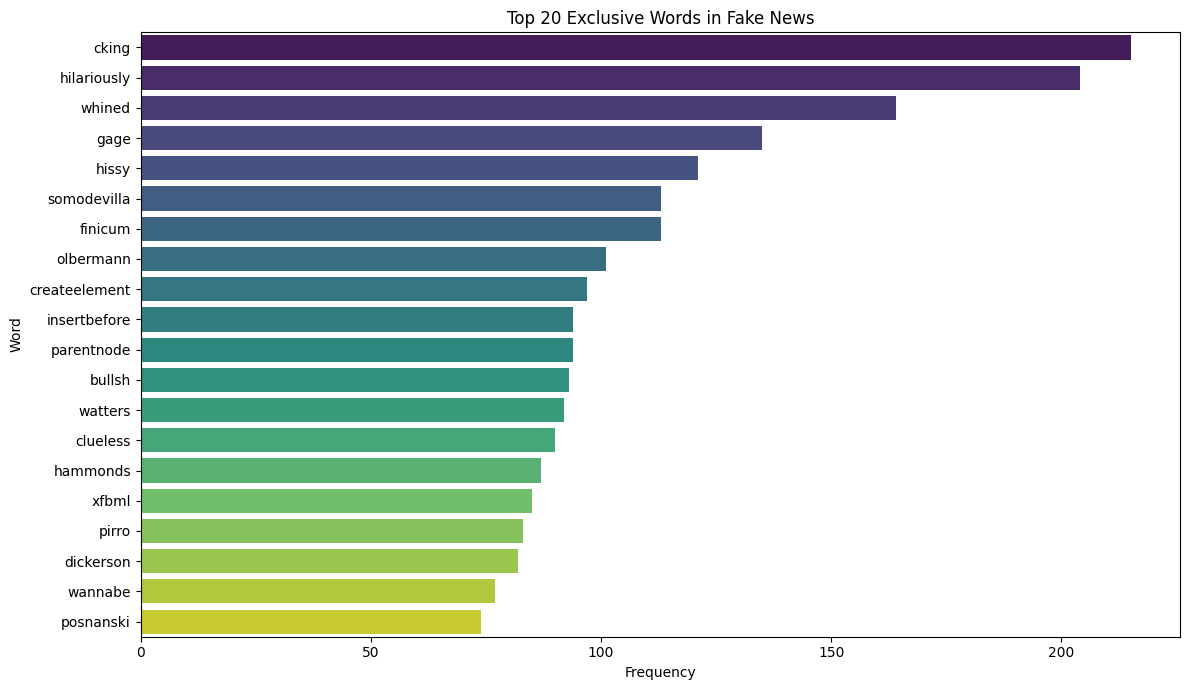

/tmp/ipykernel_2751/1938708299.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_real_counts, y=top_real_words, palette='magma')


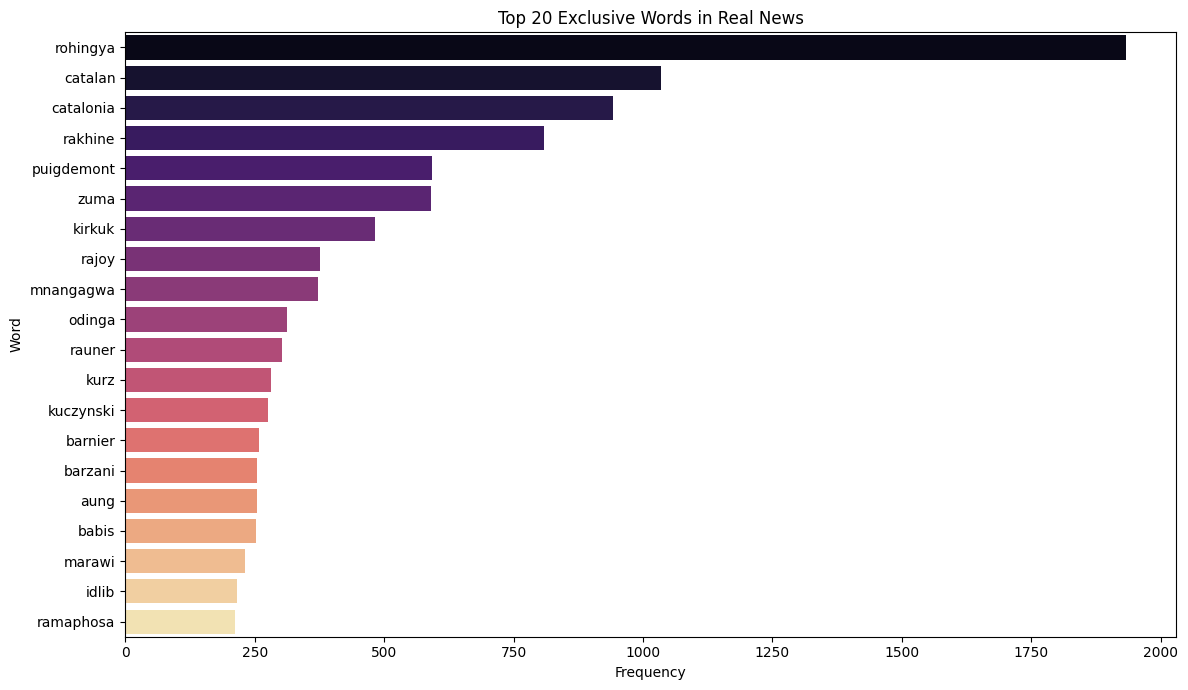

In [ ]:
if (DATABASE == "ISOT"):
  training_df = pd.concat([train_df, val_df], ignore_index=True)
  sorted_exclusive_fake, sorted_exclusive_real = countExclusiveWords(
      training_df[training_df['label'] == 0],
      training_df[training_df['label'] == 1],
      "input_text"
  )

  # Prepare data for plotting
  top_fake_words = [word for word, count in sorted_exclusive_fake[:20]]
  top_fake_counts = [count for word, count in sorted_exclusive_fake[:20]]

  top_real_words = [word for word, count in sorted_exclusive_real[:20]]
  top_real_counts = [count for word, count in sorted_exclusive_real[:20]]

  # Plotting for Exclusive Fake Words
  plt.figure(figsize=(12, 7))
  sns.barplot(x=top_fake_counts, y=top_fake_words, palette='viridis')
  plt.title('Top 20 Exclusive Words in Fake News')
  plt.xlabel('Frequency')
  plt.ylabel('Word')
  plt.tight_layout()
  plt.show()

  # Plotting for Exclusive Real Words
  plt.figure(figsize=(12, 7))
  sns.barplot(x=top_real_counts, y=top_real_words, palette='magma')
  plt.title('Top 20 Exclusive Words in Real News')
  plt.xlabel('Frequency')
  plt.ylabel('Word')
  plt.tight_layout()
  plt.show()

else:
    print("Not ISOT")

## 7. Tokenization & Lemmatization

- Regex-based word tokenization
- Optional stopword removal
- Optional lemmatization (WordNet)

In [ ]:
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?", re.IGNORECASE)
STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()


def tokenize(text: str, remove_stopwords=REMOVE_STOPWORDS, use_lemmatization=USE_LEMMATIZATION) -> list:
    """Tokenize, optionally remove stopwords and lemmatize."""
    tokens = TOKEN_RE.findall(text.lower())
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP_WORDS]
    if use_lemmatization:
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    return tokens

In [ ]:
train_df["tokens"] = train_df["input_text"].apply(tokenize)
val_df["tokens"] = val_df["input_text"].apply(tokenize)
test_df["tokens"] = test_df["input_text"].apply(
    lambda x: tokenize(x, remove_stopwords=False, use_lemmatization=False)
)

print(f"Tokenized {len(train_df) + len(val_df)} texts")
print(f"Example tokens (first 20): {train_df.loc[0, 'tokens'][:20]}")

Tokenized 30155 texts
Example tokens (first 20): ['white', 'vega', 'teen', 'caught', 'camera', 'calling', 'black', 'student', 'cking', 'vega', 'high', 'school', 'student', 'caught', 'camera', 'calling', 'african', 'american', 'classmate', 'cking']


## 8. Build Vocabulary

To build the vocabulary was only use the train set only

In [ ]:
def build_vocab(token_lists, vocab_size=VOCAB_SIZE, min_freq=MIN_FREQ):
    """Build vocabulary from lists of tokens. Returns stoi, itos, counter."""
    counter = Counter()
    for tokens in token_lists:
        counter.update(tokens)

    filtered = [tok for tok, c in counter.most_common() if c >= min_freq]

    # Exclude specified words from the vocabulary
    words_to_exclude = {'rohingya', 'catalan', 'catalonia'}
    filtered = [tok for tok in filtered if tok not in words_to_exclude]

    filtered = filtered[:max(0, vocab_size - 2)]  # reserve space for PAD and UNK

    itos = [PAD_TOKEN, UNK_TOKEN] + filtered
    stoi = {tok: i for i, tok in enumerate(itos)}
    return stoi, itos, counter

In [ ]:
stoi, itos, word_counter = build_vocab(train_df["tokens"])
actual_vocab_size = len(stoi)

print(f"Vocabulary: {actual_vocab_size} tokens (from {len(word_counter)} unique, min_freq={MIN_FREQ})")
print(f"Most common: {word_counter.most_common(10)}")

Vocabulary: 2000 tokens (from 65741 unique, min_freq=2)
Most common: [('trump', 87789), ('said', 80412), ('state', 35344), ('would', 31924), ('president', 31468), ('republican', 26531), ('year', 22798), ('people', 22601), ('house', 17740), ('donald', 17264)]


/tmp/ipykernel_2751/1295182740.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


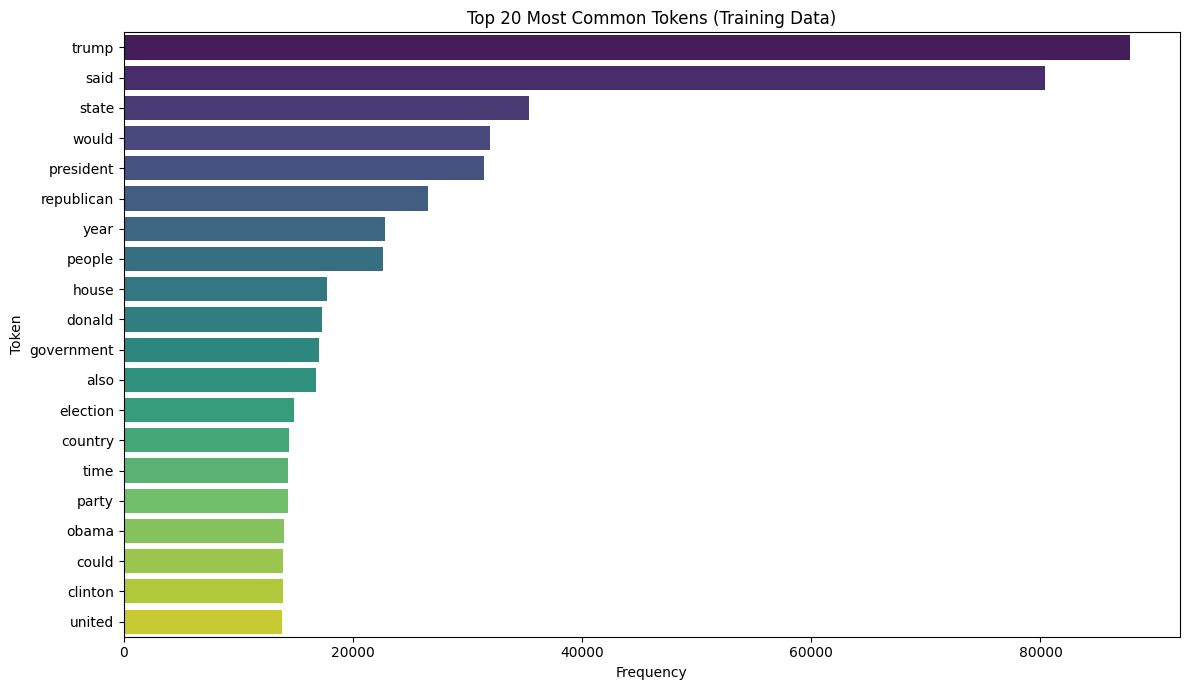

In [ ]:
# Get the most common words and their counts
top_n = 20  # You can adjust this number
most_common_words = word_counter.most_common(top_n)

# Prepare data for plotting
words = [word for word, count in most_common_words]
counts = [count for word, count in most_common_words]

# Create the histogram plot
plt.figure(figsize=(12, 7))
sns.barplot(x=counts, y=words, palette='viridis')
plt.title(f'Top {top_n} Most Common Tokens (Training Data)')
plt.xlabel('Frequency')
plt.ylabel('Token')
plt.tight_layout()
plt.show()

## 10. Convert Tokens to Padded ID Sequences

In [ ]:
def text_to_ids(tokens: list, stoi: dict, max_len: int = MAX_LENGTH) -> list:
    """Convert token list to padded/truncated list of IDs."""
    ids = [stoi.get(tok, UNK_ID) for tok in tokens]
    ids = ids[:max_len]                           # truncate
    ids = ids + [PAD_ID] * (max_len - len(ids))   # pad
    return ids

### 10.1 ISOT Dataset

In [ ]:
train_ids = [text_to_ids(tokens, stoi) for tokens in train_df["tokens"]]
val_ids = [text_to_ids(tokens, stoi) for tokens in val_df["tokens"]]
test_ids = [text_to_ids(tokens, stoi) for tokens in test_df["tokens"]]

print(f"Converted to ID sequences (max_len={MAX_LENGTH})")
print(f"Example IDs (first 20): {train_ids[0][:20]}")

Converted to ID sequences (max_len=512)
Example IDs (first 20): [24, 1, 1, 1334, 1927, 440, 177, 425, 1, 1, 212, 197, 425, 1334, 1927, 440, 680, 27, 1, 1]


## 11. Create Tensors

In [ ]:
def print_tensor_info(x_t, y_t, x_v, y_v, x_te, y_te):
    print(f"X_train: {x_t.shape}")
    print(f"y_train: {y_t.shape}  (fake={int((y_t == 0).sum())}, true={int((y_t == 1).sum())})")
    print(f"X_val:   {x_v.shape}")
    print(f"y_val:   {y_v.shape}  (fake={int((y_v == 0).sum())}, true={int((y_v == 1).sum())})")
    print(f"X_test:  {x_te.shape}")
    print(f"y_test:  {y_te.shape}   (fake={int((y_te == 0).sum())}, true={int((y_te == 1).sum())})")

### 11.1 ISOT Dataset

In [ ]:
X_train = torch.tensor(train_ids, dtype=torch.long)
y_train = torch.tensor(train_df["label"].tolist(), dtype=torch.float)
X_val = torch.tensor(val_ids, dtype=torch.long)
y_val = torch.tensor(val_df["label"].tolist(), dtype=torch.float)
X_test = torch.tensor(test_ids, dtype=torch.long)
y_test = torch.tensor(test_df["label"].tolist(), dtype=torch.float)

print_tensor_info(X_train, y_train, X_val, y_val, X_test, y_test)


X_train: torch.Size([24124, 512])
y_train: torch.Size([24124])  (fake=9019, true=15105)
X_val:   torch.Size([6031, 512])
y_val:   torch.Size([6031])  (fake=2255, true=3776)
X_test:  torch.Size([3351, 512])
y_test:  torch.Size([3351])   (fake=1253, true=2098)


## 12. Save Artifacts

These will be loaded by the training notebooks.

In [ ]:
os.makedirs(f"{ARTIFACTS_DIR}/{DATABASE}", exist_ok=True)

# Save tensors
torch.save(X_train, os.path.join(f"{ARTIFACTS_DIR}/{DATABASE}", "train_ids.pt"))
torch.save(y_train, os.path.join(f"{ARTIFACTS_DIR}/{DATABASE}", "train_labels.pt"))
torch.save(X_val, os.path.join(f"{ARTIFACTS_DIR}/{DATABASE}", "val_ids.pt"))
torch.save(y_val, os.path.join(f"{ARTIFACTS_DIR}/{DATABASE}", "val_labels.pt"))
torch.save(X_test, os.path.join(f"{ARTIFACTS_DIR}/{DATABASE}", "test_ids.pt"))
torch.save(y_test, os.path.join(f"{ARTIFACTS_DIR}/{DATABASE}", "test_labels.pt"))
# Save vocabulary
with open(os.path.join(f"{ARTIFACTS_DIR}/{DATABASE}", "stoi.json"), "w") as f:
    json.dump(stoi, f)
with open(os.path.join(f"{ARTIFACTS_DIR}/{DATABASE}", "itos.json"), "w") as f:
    json.dump(itos, f)


In [ ]:
# Save a summary for quick inspection
summary = {
    "vocab_size": actual_vocab_size,
    "max_length": MAX_LENGTH,
    "train_samples": len(train_df),
    "val_samples": len(val_df),
    "test_samples": len(test_df),
    "train_fake": int((y_train == 0).sum()),
    "train_true": int((y_train == 1).sum()),
    "val_fake": int((y_val == 0).sum()),
    "val_true": int((y_val == 1).sum()),
    "test_fake": int((y_test == 0).sum()),
    "test_true": int((y_test == 1).sum()),
}
with open(os.path.join(f"{ARTIFACTS_DIR}/{DATABASE}", "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print(f"Artifacts saved to {ARTIFACTS_DIR}/{DATABASE}/")
print(f"  train_ids.pt      : {X_train.shape}")
print(f"  train_labels.pt   : {y_train.shape}")
print(f"  val_ids.pt        : {X_val.shape}")
print(f"  val_labels.pt     : {y_val.shape}")
print(f"  test_ids.pt       : {X_test.shape}")
print(f"  test_labels.pt    : {y_test.shape}")
print(f"  stoi.json         : {actual_vocab_size} tokens")
print(f"  itos.json         : {actual_vocab_size} tokens")
print(f"  summary.json      : dataset stats")
print("\nPreprocessing complete. You can now run the training notebook.")

Artifacts saved to /content/drive/MyDrive/aidl-final-project/artifacts/ISOT/
  train_ids.pt      : torch.Size([24124, 512])
  train_labels.pt   : torch.Size([24124])
  val_ids.pt        : torch.Size([6031, 512])
  val_labels.pt     : torch.Size([6031])
  test_ids.pt       : torch.Size([3351, 512])
  test_labels.pt    : torch.Size([3351])
  stoi.json         : 2000 tokens
  itos.json         : 2000 tokens
  summary.json      : dataset stats

Preprocessing complete. You can now run the training notebook.


In [ ]:
# Quick verification
print(json.dumps(summary, indent=2))
!ls -lah {ARTIFACTS_DIR}/

{
  "vocab_size": 2000,
  "max_length": 512,
  "train_samples": 24124,
  "val_samples": 6031,
  "test_samples": 3351,
  "train_fake": 9019,
  "train_true": 15105,
  "val_fake": 2255,
  "val_true": 3776,
  "test_fake": 1253,
  "test_true": 2098
}
total 133M
drwx------ 2 root root 4.0K Mar 17 18:22 ISOT
-rw------- 1 root root 498K Mar  9 07:01 itos.json
drwx------ 2 root root 4.0K Mar 17 18:17 LIAR
-rw------- 1 root root  358 Mar 14 19:19 most_fake_words.csv
-rw------- 1 root root  617 Mar 14 19:19 most_true_words.csv
-rw------- 1 root root 795K Mar  9 07:01 stoi.json
-rw------- 1 root root  247 Mar  9 07:01 summary.json
-rw------- 1 root root  14M Mar  9 07:01 test_ids.pt
-rw------- 1 root root  15K Mar  9 07:01 test_labels.pt
-rw------- 1 root root 107M Mar  9 07:01 train_ids.pt
-rw------- 1 root root 108K Mar  9 07:01 train_labels.pt
-rw------- 1 root root  12M Mar  9 07:01 val_ids.pt
-rw------- 1 root root  14K Mar  9 07:01 val_labels.pt
